In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1: DATA EXTRACTION & BUSINESS LOGIC APPLICATION (UPDATED SOURCE)
# ==============================================================================
# Purpose: 1. Extract data from 'v_ML_Supervised' (The correct view).
#          2. Apply the "Salchichota" grouping logic exactly as requested.
#          3. Apply the Master Coalesce logic.
# ==============================================================================

# --- 1. EXTRACT RAW DATA FROM VIEW ---
print("⏳ Extracting data from v_ML_Supervised...")
query = """
SELECT
    offer_id,
    dropoff_address,
    dropoff_polygon_id,
    dropoff_hdbscan_id,
    dropoff_polygon_name,
    dropoff_hdbscan_name
FROM v_ML_Supervised
WHERE dropoff_address IS NOT NULL
"""
df_input = pd.read_sql(query, db_engine)
print(f"✅ Loaded {len(df_input)} records.")


# --- 2. STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION ---
print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
# Aseguramos manejo de NaNs antes de mapear
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(
    lambda x: "__".join(sorted([str(i) for i in x if pd.notna(i)]))
).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'),
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)


# --- 3. MASTER COALESCE & PREPARATION ---
print("⏳ Executing Master Coalesce...")

# A. Logic for final_zone_id
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].fillna(-1).astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],
    df_input['dropoff_hdbscan_name']
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# Filter training set
df_training = df_input[df_input['final_zone_name'] != "Unassigned Area"].copy()

print(f"\n✅ Data Preparation Complete.")
print(f"Total Records: {len(df_input)}")
print(f"Training Records: {len(df_training)}")
print(f"Unique Targets: {df_training['final_zone_id'].nunique()}")

⏳ Extracting data from v_ML_Supervised...
✅ Loaded 4764 records.
⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2186
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


⏳ Executing Master Coalesce...

✅ Data Preparation Complete.
Total Records: 4764
Training Records: 3399
Unique Targets: 66


In [ ]:
# ==============================================================================
# CELL 1.3: MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES) - UPDATED SOURCE
# ==============================================================================
# Purpose: Execute the definitive logic:
#          1. IF Polygon exists -> Use P_ID and Salchichota Name.
#          2. ELSE IF HDBSCAN exists -> Use C_ID and Machine Name.
#          3. ELSE -> Unassigned.
#          No changes to logic. Just ensuring it runs on the loaded df_input.
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].fillna(-1).astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
# Records where we have BOTH a polygon and a cluster. Polygon must win.
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
# Records with NO polygon (-1) but WITH a cluster (> -1). Cluster must win.
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
# Records with neither.
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

# --- 3. FILTER TRAINING SET ---
# We define df_training here to be used by subsequent cells
df_training = df_input[df_input['final_zone_name'] != "Unassigned Area"].copy()
print(f"\n✅ Ready for Training. Dataset Size: {len(df_training)}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2578
Solved by Machine (C_): 821

✅ Ready for Training. Dataset Size: 3399


In [ ]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


In [ ]:
# ==============================================================================
# CELL 1.5: CLASS IMBALANCE AUDIT & PURGE
# ==============================================================================
# Purpose: 1. Identify zones with < 2 records (which break stratified split).
#          2. Automatically remove them from the training set.
# ==============================================================================

print("🕵️‍♂️ Starting Forensic Audit of Class Counts...")

# 1. Contamos frecuencias
zone_counts = df_training['final_zone_id'].value_counts()

# 2. Identificamos los culpables (Clases con menos de 2 ejemplos)
# Nota: Si quieres ser más estricto, cambia el 2 por 5 o 10.
MIN_SAMPLES = 2
rare_zones = zone_counts[zone_counts < MIN_SAMPLES].index.tolist()

# 3. Reporte de los culpables
if len(rare_zones) > 0:
    print(f"\n🔴 CRITICAL: Found {len(rare_zones)} zones with fewer than {MIN_SAMPLES} records.")
    print("These zones would crash the Stratified Split. They are:")

    # Mostramos los nombres para que sepas qué estamos borrando
    for zone_id in rare_zones:
        name = zone_map.get(zone_id, "Unknown Name")
        count = zone_counts[zone_id]
        print(f"   - ID: {zone_id} | Name: {name} | Count: {count}")

    # 4. LA PURGA (Filtrado)
    print(f"\n✂️ Purging {len(rare_zones)} rare classes from training set...")
    initial_len = len(df_training)
    df_training = df_training[~df_training['final_zone_id'].isin(rare_zones)].copy()
    final_len = len(df_training)

    print(f"✅ Purge Complete. Rows dropped: {initial_len - final_len}")
    print(f"   New Training Size: {final_len}")

else:
    print("\n✅ All zones have sufficient data. No purge needed.")

# 5. Verificación final
print("\n--- Top 5 Least Populated Zones (After Purge) ---")
print(df_training['final_zone_id'].value_counts().tail(5))

🕵️‍♂️ Starting Forensic Audit of Class Counts...

🔴 CRITICAL: Found 2 zones with fewer than 2 records.
These zones would crash the Stratified Split. They are:
   - ID: C_32 | Name: tacubaya | Count: 1
   - ID: C_18 | Name: santa_fe_patio | Count: 1

✂️ Purging 2 rare classes from training set...
✅ Purge Complete. Rows dropped: 2
   New Training Size: 3397

--- Top 5 Least Populated Zones (After Purge) ---
final_zone_id
P_41    21
C_13    12
C_19     8
C_16     6
C_15     5
Name: count, dtype: int64


In [ ]:
# ==============================================================================
# CELL 1.X: PURE DISTRIBUTION AUDIT
# ==============================================================================
# Purpose: Get the raw count of unique values for Polygon and HDBSCAN names independently.
#          This clarifies exactly how many records belong to 'santa_fe_patio' in each system.
# ==============================================================================

# 1. Cargar datos completos de la vista
query_full = """
SELECT dropoff_polygon_name, dropoff_hdbscan_name
FROM v_ML_Supervised
"""
df_full = pd.read_sql(query_full, db_engine)

print(f"✅ Total Rows Loaded: {len(df_full)}")

# 2. Distribución de Polygon Names
print("\n" + "="*40)
print("LAYER 1: HUMAN POLYGONS (dropoff_polygon_name)")
print("="*40)
poly_counts = df_full['dropoff_polygon_name'].value_counts().reset_index()
poly_counts.columns = ['Zone Name', 'Count']
display(poly_counts.head(20)) # Top 20

# Verificar específicos
print("\n--- Specific Check (Polygon) ---")
print(poly_counts[poly_counts['Zone Name'].str.contains('santa_fe|tacubaya', case=False, na=False)])


# 3. Distribución de HDBSCAN Names
print("\n" + "="*40)
print("LAYER 2: MACHINE CLUSTERS (dropoff_hdbscan_name)")
print("="*40)
hdb_counts = df_full['dropoff_hdbscan_name'].value_counts().reset_index()
hdb_counts.columns = ['Zone Name', 'Count']
display(hdb_counts.head(20)) # Top 20

# Verificar específicos
print("\n--- Specific Check (HDBSCAN) ---")
print(hdb_counts[hdb_counts['Zone Name'].str.contains('santa_fe|tacubaya', case=False, na=False)])

✅ Total Rows Loaded: 4765

LAYER 1: HUMAN POLYGONS (dropoff_polygon_name)


,Zone Name,Count
0,unassigned,2187
1,roma_condesa_2,223
2,santa_fe_centro_comercial,169
3,santa_fe_ibero,150
4,carso_antara_miyana,122
5,herradura_conscripto,99
6,sante_fe_patio,91
7,tamarindos,82
8,rios,76
9,palmas_jp_morgan,64



--- Specific Check (Polygon) ---
                    Zone Name  Count
2   santa_fe_centro_comercial    169
3              santa_fe_ibero    150
30               santa_fe_tec     29
37          santa_fe_colegios     21
51          santa_fe_quintana     13
57        santa_fe_cumbres_de     10
66        santa_fe_bosques_de      7

LAYER 2: MACHINE CLUSTERS (dropoff_hdbscan_name)


,Zone Name,Count
0,unassigned,2139
1,santa_fe_core,331
2,carso_antara_miyana,170
3,terminal_1_aicm,111
4,terminal_2_aicm,111
5,sotelo_san_esteban,104
6,el_semaforo_de_palmas,96
7,tamarindos,85
8,interlomas_magnocentro,85
9,campos_eliseos,75



--- Specific Check (HDBSCAN) ---
         Zone Name  Count
1    santa_fe_core    331
13  santa_fe_patio     64
27    santa_fe_abc     36
28  santa_fe_itesm     35
35        tacubaya     30


In [ ]:
# ==============================================================================
# CELL 2: PREPROCESSING & VECTORIZATION (TEXT TO TENSORS)
# ==============================================================================
# Purpose: 1. Build vocabularies (Address Tokens -> Int, Zone ID -> Int).
#          2. Convert data to PyTorch Tensors.
#          3. Create DataLoaders for training.
# ==============================================================================

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import regex as re

# --- 1. CONFIGURATION ---
MAX_LEN = 40  # Maximum length of address sequence
BATCH_SIZE = 32
VOCAB_SIZE = 2500 # Limit vocabulary to top 2500 tokens (for robustness)

# --- 2. TOKENIZATION UTILS ---
def simple_tokenizer(text):
    if not isinstance(text, str): return []
    text = text.lower()
    return re.findall(r'[\w]+', text) # Simple alphanumeric tokenization

# --- 3. BUILD VOCABULARIES ---
print("⏳ Building Vocabularies...")

# A. Address Vocabulary (Tokens)
all_tokens = [token for addr in df_training['dropoff_address'] for token in simple_tokenizer(addr)]
token_counts = Counter(all_tokens)
# Top N tokens + Special Tokens
vocab_tokens = ['<pad>', '<unk>'] + [token for token, count in token_counts.most_common(VOCAB_SIZE)]
token_to_idx = {token: i for i, token in enumerate(vocab_tokens)}

# B. Target Vocabulary (Zone IDs)
# We need to map our P_25, C_1 strings to integers 0, 1, 2...
unique_zones = sorted(df_training['final_zone_id'].unique())
zone_to_idx = {zone: i for i, zone in enumerate(unique_zones)}
idx_to_zone = {i: zone for i, zone in enumerate(unique_zones)}

print(f"✅ Vocab Size: {len(token_to_idx)}")
print(f"✅ Number of Classes (Zones): {len(unique_zones)}")

# --- 4. DATASET CLASS ---
class AddressDataset(Dataset):
    def __init__(self, addresses, labels, token_to_idx, zone_to_idx, max_len):
        self.addresses = addresses
        self.labels = labels
        self.token_to_idx = token_to_idx
        self.zone_to_idx = zone_to_idx
        self.max_len = max_len

    def __len__(self):
        return len(self.addresses)

    def __getitem__(self, idx):
        # 1. Tokenize
        tokens = simple_tokenizer(self.addresses[idx])

        # 2. Convert to Indices (with <unk> handling)
        indices = [self.token_to_idx.get(t, self.token_to_idx['<unk>']) for t in tokens]

        # 3. Pad or Truncate
        if len(indices) < self.max_len:
            indices += [self.token_to_idx['<pad>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        # 4. Get Label Index
        label = self.zone_to_idx[self.labels[idx]]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# --- 5. SPLIT & LOADERS ---
X = df_training['dropoff_address'].values
y = df_training['final_zone_id'].values

# Stratified Split (Crucial for class balance)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_dataset = AddressDataset(X_train, y_train, token_to_idx, zone_to_idx, MAX_LEN)
val_dataset = AddressDataset(X_val, y_val, token_to_idx, zone_to_idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(f"✅ DataLoaders Ready. Train Size: {len(X_train)}, Val Size: {len(X_val)}")

⏳ Building Vocabularies...
✅ Vocab Size: 2408
✅ Number of Classes (Zones): 64
✅ DataLoaders Ready. Train Size: 2717, Val Size: 680


In [ ]:
# ==============================================================================
# CELL 3: MODEL ARCHITECTURE - THE TRANSFORMER CLASSIFIER
# ==============================================================================
# Architecture: Embedding -> PositionalEncoding -> TransformerEncoder -> Linear Head
# ==============================================================================

import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ZoneClassifierTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=128, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        # Layers
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=256, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification Head (Global Average Pooling + Linear)
        self.classifier = nn.Linear(d_model, num_classes)
        self.d_model = d_model

    def forward(self, x):
        # x shape: [batch_size, seq_len]

        # 1. Embed & Position
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x) # shape: [batch_size, seq_len, d_model]

        # 2. Transformer Encoder
        # We create a padding mask so the model ignores <pad> tokens
        # (This is an advanced detail, PyTorch handles it if we pass src_key_padding_mask)
        # For simplicity in this MVP, we'll let it attend to pads (minor noise) or we can mask.
        x = self.transformer_encoder(x)

        # 3. Pooling (Reduce sequence to single vector)
        # We take the mean across the sequence length dimension
        x = x.mean(dim=1) # shape: [batch_size, d_model]

        # 4. Classify
        logits = self.classifier(x) # shape: [batch_size, num_classes]
        return logits

# Instantiate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

model = ZoneClassifierTransformer(
    vocab_size=len(token_to_idx),
    num_classes=len(unique_zones),
    d_model=128, # Can increase if complex
    nhead=4,
    num_layers=2 # 2 layers is often enough for simple text
).to(device)

print("✅ Model Architected & Moved to GPU.")

🚀 Using Device: cpu
✅ Model Architected & Moved to GPU.


In [ ]:
# ==============================================================================
# CELL 4: TRAINING LOOP
# ==============================================================================

import torch.optim as optim
from sklearn.metrics import accuracy_score

# Hyperparams
EPOCHS = 10
LR = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"🏁 Starting Training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation Loop
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {acc:.4f}")

print("✅ Training Complete.")

🏁 Starting Training for 10 epochs...
Epoch 1/10 | Train Loss: 2.7604 | Val Loss: 1.7978 | Val Acc: 0.5015
Epoch 2/10 | Train Loss: 1.3908 | Val Loss: 1.2646 | Val Acc: 0.6279
Epoch 3/10 | Train Loss: 0.9397 | Val Loss: 1.0831 | Val Acc: 0.6868
Epoch 4/10 | Train Loss: 0.7082 | Val Loss: 0.9646 | Val Acc: 0.7382
Epoch 5/10 | Train Loss: 0.5238 | Val Loss: 0.8415 | Val Acc: 0.7618
Epoch 6/10 | Train Loss: 0.4249 | Val Loss: 0.8478 | Val Acc: 0.7691
Epoch 7/10 | Train Loss: 0.3373 | Val Loss: 0.8497 | Val Acc: 0.7603
Epoch 8/10 | Train Loss: 0.2711 | Val Loss: 0.8544 | Val Acc: 0.7794
Epoch 9/10 | Train Loss: 0.2476 | Val Loss: 0.8832 | Val Acc: 0.7779
Epoch 10/10 | Train Loss: 0.1883 | Val Loss: 0.8952 | Val Acc: 0.7926
✅ Training Complete.


In [ ]:
# ==============================================================================
# CELL 5: INFERENCE ENGINE (TEXT TO ZONE)
# ==============================================================================

def predict_zone(address_text):
    model.eval()
    # 1. Preprocess
    tokens = simple_tokenizer(address_text)
    indices = [token_to_idx.get(t, token_to_idx['<unk>']) for t in tokens]

    # Pad/Truncate
    if len(indices) < MAX_LEN:
        indices += [token_to_idx['<pad>']] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    tensor_in = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    # 2. Predict
    with torch.no_grad():
        logits = model(tensor_in)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    # 3. Decode
    zone_id = idx_to_zone[pred_idx]
    zone_name = zone_map.get(zone_id, "Unknown Name")

    return zone_name, confidence

# --- TEST DRIVE ---
test_addresses = [
    "Av. Presidente Masaryk 101, Polanco",
    "Paseo de la Reforma 505, Lomas",
    "Calle cualquiera en Santa Fe",
    "Aeropuerto Terminal 2 puerta 4"
]

print("\n🤖 OPUS NAVIGATOR PREDICTIONS:")
print("-" * 60)
for addr in test_addresses:
    zone, conf = predict_zone(addr)
    print(f"📍 Address: {addr}")
    print(f"   --> Predicted Zone: {zone} ({conf*100:.1f}%)")
    print("-" * 60)


🤖 OPUS NAVIGATOR PREDICTIONS:
------------------------------------------------------------
📍 Address: Av. Presidente Masaryk 101, Polanco
   --> Predicted Zone: polanco_parroquia (74.8%)
------------------------------------------------------------
📍 Address: Paseo de la Reforma 505, Lomas
   --> Predicted Zone: interlomas_haciendas__jesus_del_monte (42.0%)
------------------------------------------------------------
📍 Address: Calle cualquiera en Santa Fe
   --> Predicted Zone: santa_fe_ibero (97.3%)
------------------------------------------------------------
📍 Address: Aeropuerto Terminal 2 puerta 4
   --> Predicted Zone: terminal_2_aicm (79.3%)
------------------------------------------------------------


In [ ]:
# ==============================================================================
# CELL 6: VALIDATION AUDIT (REALITY CHECK)
# ==============================================================================
# Purpose: Compare Real vs. Predicted zones on the unseen Validation Set.
# ==============================================================================

import pandas as pd

# 1. Función para decodificar índices de vuelta a texto
def decode_address(indices):
    tokens = []
    for idx in indices:
        if idx == token_to_idx['<pad>']: continue
        # Buscamos el token en el vocabulario (un poco lento, pero sirve para demo)
        for t, i in token_to_idx.items():
            if i == idx:
                tokens.append(t)
                break
    return " ".join(tokens)

# 2. Ejecutar Inferencia en un lote de validación
model.eval()
audit_results = []

# Tomamos solo el primer lote del val_loader para no saturar
inputs, labels = next(iter(val_loader))
inputs, labels = inputs.to(device), labels.to(device)

with torch.no_grad():
    logits = model(inputs)
    probs = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probs, dim=1)

# 3. Construir la Tabla de Auditoría
for i in range(len(inputs)):
    # Decodificar dirección (input)
    raw_indices = inputs[i].cpu().tolist()
    address_text = decode_address(raw_indices)

    # Decodificar zonas (Real vs Pred)
    real_zone_id = idx_to_zone[labels[i].item()]
    pred_zone_id = idx_to_zone[predictions[i].item()]

    real_name = zone_map.get(real_zone_id, "Unknown")
    pred_name = zone_map.get(pred_zone_id, "Unknown")

    confidence = probs[i][predictions[i]].item()

    # Check de éxito
    is_correct = (real_zone_id == pred_zone_id)

    audit_results.append({
        'Address (Tokenized)': address_text,
        'Real Zone': real_name,
        'Predicted Zone': pred_name,
        'Confidence': f"{confidence:.1%}",
        'Correct': "✅" if is_correct else "❌"
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_results)

print(f"--- VALIDATION BATCH AUDIT (N={len(df_audit)}) ---")
print(f"Batch Accuracy: {df_audit['Correct'].value_counts(normalize=True).get('✅', 0):.1%}")
display(df_audit)

--- VALIDATION BATCH AUDIT (N=32) ---
Batch Accuracy: 84.4%


,Address (Tokenized),Real Zone,Predicted Zone,Confidence,Correct
0,aeroméxico col peñón de los baños,terminal_2_aicm,terminal_2_aicm,54.1%,✅
1,blv magnocentro sur 2 col san fernando la herradura 52760 huixquilucan em interlomas,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,98.7%,✅
2,kaspe comercio 2 col pedregal 24 lomas virreyes molino del rey miguel hidalgo 11040 ciudad de méxico cdmx méxico lomas de chapultepec,lomas_virreyes,lomas_virreyes,90.0%,✅
3,calle alcanfores 25 san josé de los cedros 05200 cuajimalpa de morelos cuajimalpa,cruce_echanove,cruce_echanove,99.5%,✅
4,p º de los tamarindos 90 local ml 02 bosques de las lomas cuajimalpa de morelos 05110 ciudad de méxico cdmx méxico,tamarindos,tamarindos,99.7%,✅
5,blvd magnocentro 27 bosque de las palmas 52786 naucalpan de juárez méx méxico piso 2 naucalpan de juárez méx méxico interlomas,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,99.7%,✅
6,calle josé maría morelos calle mariano matamoros méxico d f,viaducto_tlalpan,cruce_echanove,48.1%,❌
7,av bernardo quintana 41 santa fe la loma álvaro obregón 01376 ciudad de méxico cdmx méxico jalalpa,santa_fe_quintana__sante_fe_patio,santa_fe_quintana__sante_fe_patio,99.5%,✅
8,calz general mariano escobedo col anzures,anzures,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,53.0%,❌
9,volcan 150 lomas de chapultepec 11000 miguel hidalgo ciudad de méxico lomas de chapultepec,lomas_fc_cuernavaca,lomas_virreyes,46.8%,❌


Dimensiones: (2408, 128)
Ejecutando t-SNE...


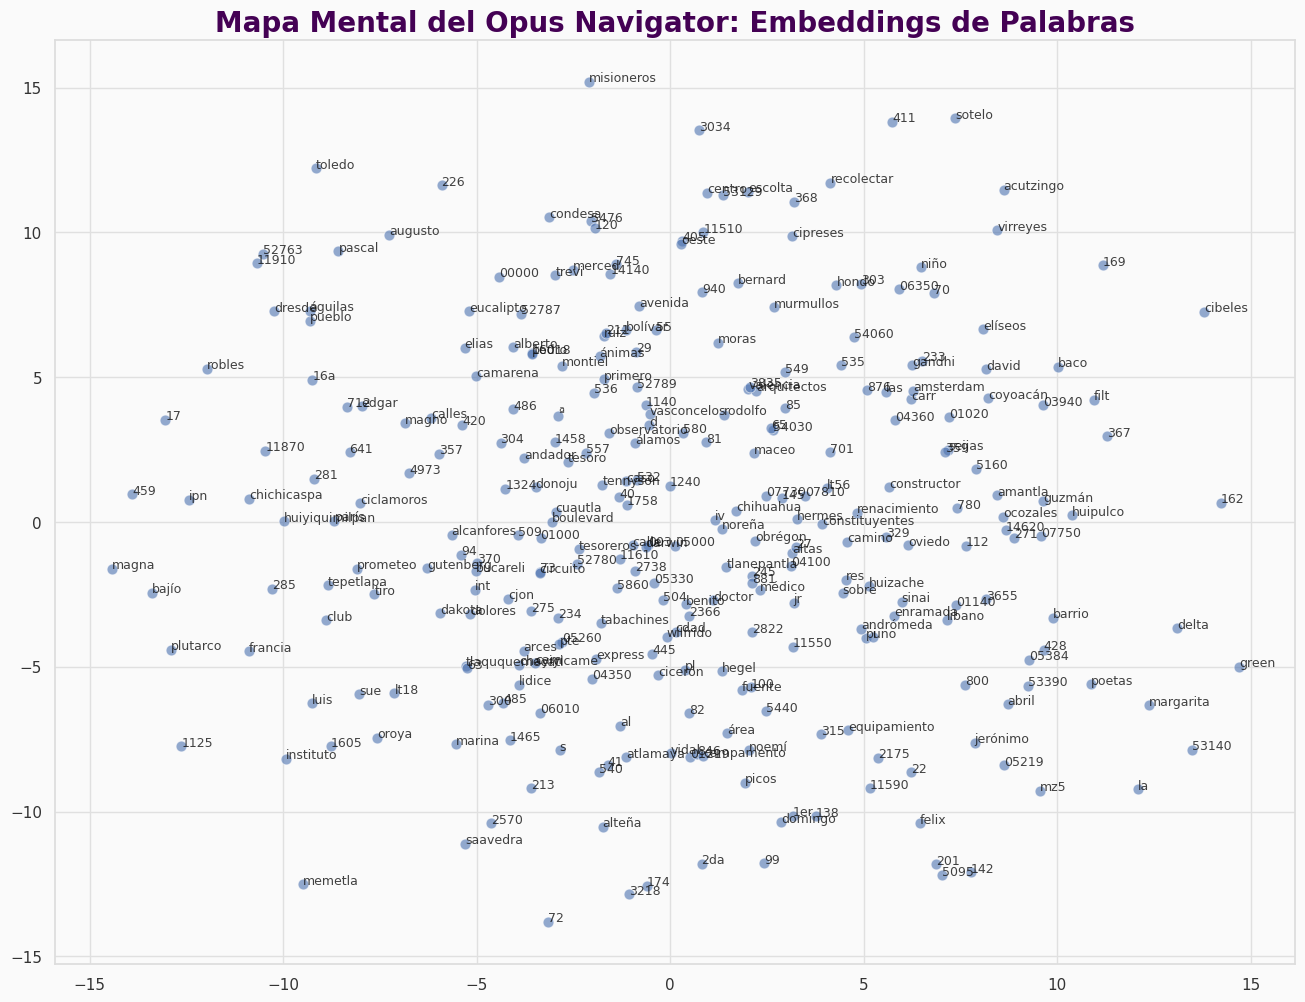

In [ ]:
# ==============================================================================
# VISUALIZACIÓN t-SNE PARA EL OPUS NAVIGATOR
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Extraer pesos (Corrección: se llama 'embedding', no 'encoder_embedding')
embedding_weights = model.embedding.weight.detach().cpu().numpy()

# 2. Etiquetas: Usamos el vocabulario de tokens (token_to_idx)
# Invertimos el diccionario para tener idx -> token
idx_to_token = {i: t for t, i in token_to_idx.items()}
labels = [idx_to_token[i] for i in range(len(idx_to_token))]

print(f"Dimensiones: {embedding_weights.shape}")
print("Ejecutando t-SNE...")

# 3. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embedding_weights)

# 4. Graficar
plt.figure(figsize=(16, 12))
plt.title("Mapa Mental del Opus Navigator: Embeddings de Palabras", fontsize=20)

# Graficamos solo una muestra aleatoria para no saturar si hay muchos puntos
# O graficamos todo si son pocos.
indices_to_plot = np.random.choice(len(labels), size=min(300, len(labels)), replace=False)

sns.scatterplot(
    x=embeddings_2d[indices_to_plot, 0],
    y=embeddings_2d[indices_to_plot, 1],
    s=60, alpha=0.6
)

for i in indices_to_plot:
    plt.annotate(
        labels[i],
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=9, alpha=0.8
    )

plt.show()

✅ Pesos extraídos exitosamente. Forma original: (2408, 128)
Iniciando proyección UMAP (Coseno)...


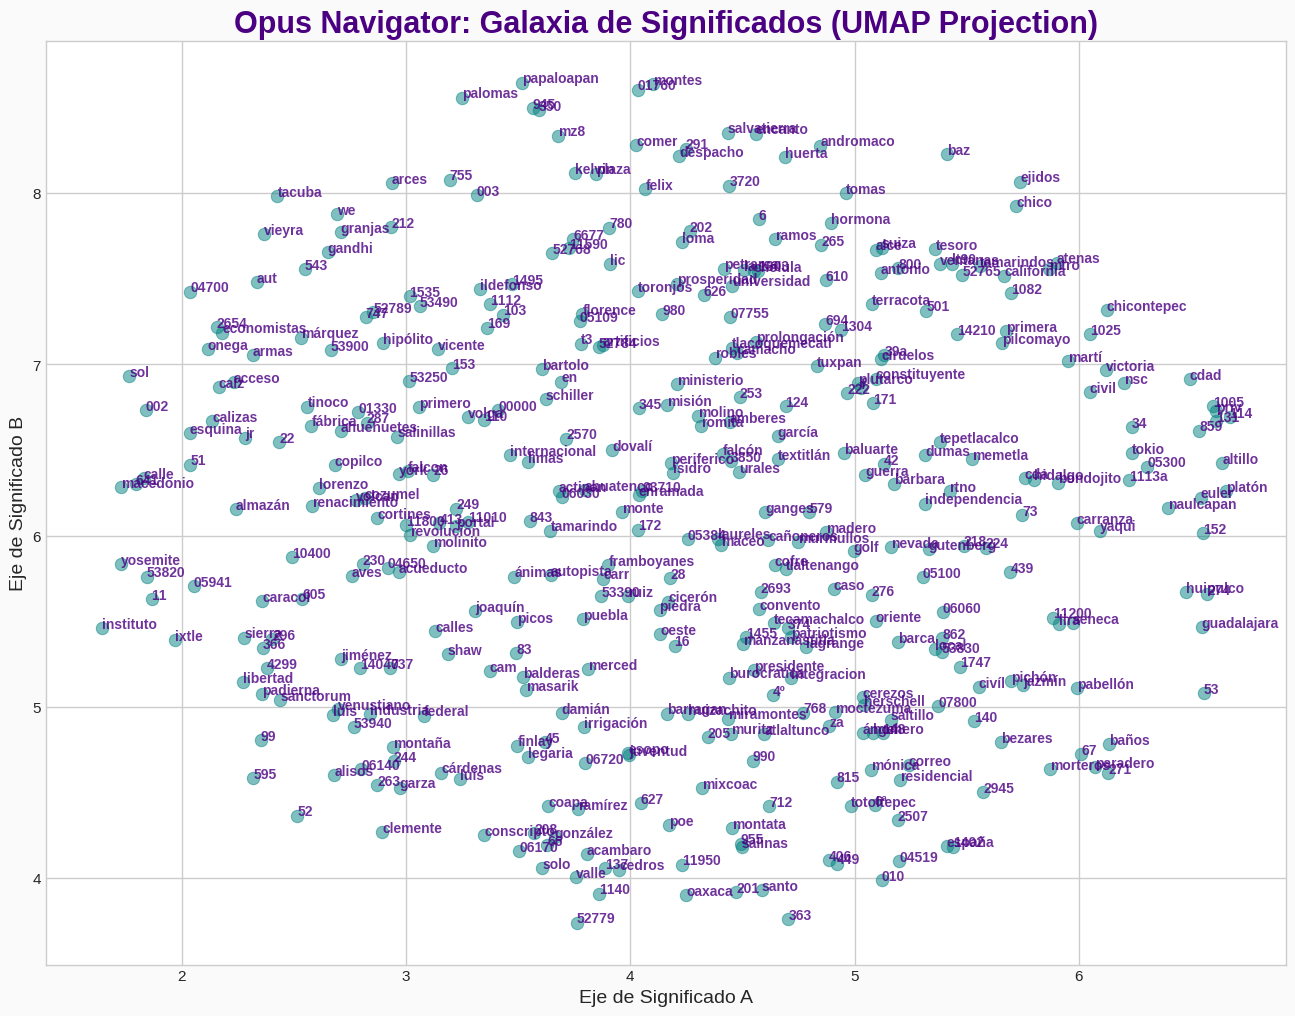

In [ ]:
# ==============================================================================
# VISUALIZACIÓN UMAP PARA EL OPUS NAVIGATOR (REEMPLAZA t-SNE)
# ==============================================================================

# 1. INSTALACIÓN DE LA LIBRERÍA (Necesaria en Colab)
try:
    import umap
except ImportError:
    print("Instalando umap-learn...")
    !pip install -q umap-learn
    import umap

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- CONFIGURACIÓN DE COLORES OPUS ---
OPUS_PURPLE = "#4B0082"
OPUS_TEAL = "#008080"

# 2. EXTRACCIÓN DE PESOS (Mismo objeto 'model' de tu celda anterior)
# Verificamos si el modelo existe en memoria para evitar el NameError
if 'model' in locals():
    # Extraemos los pesos del embedding layer
    embedding_weights = model.embedding.weight.detach().cpu().numpy()

    # Reconstrucción del diccionario de etiquetas
    idx_to_token = {i: t for t, i in token_to_idx.items()}
    labels = [idx_to_token[i] for i in range(len(idx_to_token))]

    print(f"✅ Pesos extraídos exitosamente. Forma original: {embedding_weights.shape}")
    print("Iniciando proyección UMAP (Coseno)...")

    # 3. EJECUCIÓN DE UMAP
    # Usamos metric='cosine' porque en NLP los ángulos entre vectores
    # son más importantes que la distancia euclidiana pura.
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        random_state=42
    )

    embeddings_2d = reducer.fit_transform(embedding_weights)

    # 4. RENDERIZADO VISUAL
    plt.figure(figsize=(16, 12))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Elegimos una muestra para no saturar el gráfico
    sample_size = min(400, len(labels))
    indices_to_plot = np.random.choice(len(labels), size=sample_size, replace=False)

    # Graficamos la galaxia
    sns.scatterplot(
        x=embeddings_2d[indices_to_plot, 0],
        y=embeddings_2d[indices_to_plot, 1],
        s=80,
        color=OPUS_TEAL,
        alpha=0.5,
        edgecolor=None
    )

    # Anotaciones
    for i in indices_to_plot:
        plt.annotate(
            labels[i],
            (embeddings_2d[i, 0], embeddings_2d[i, 1]),
            fontsize=10,
            alpha=0.8,
            fontweight='bold',
            color=OPUS_PURPLE
        )

    plt.title("Opus Navigator: Galaxia de Significados (UMAP Projection)", fontsize=22, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel("Eje de Significado A", fontsize=14)
    plt.ylabel("Eje de Significado B", fontsize=14)
    plt.show()

else:
    print("❌ ERROR: El objeto 'model' no está definido en esta sesión.")
    print("Por favor, ejecuta primero la celda donde defines y entrenas tu red neuronal.")